In [4]:
Shell 2 with small dataset andcorrectin for fusion

SyntaxError: invalid syntax (2640292414.py, line 1)

Fusion and Baseline successfull run for partial dataset

MMVR Human Pose Project [COMPLETE SAFE VERSION]
Device              : mps
Dataset Path        : P1
Split               : P1S1
FULL_RUN            : False
EPOCHS              : 5
BATCH_SIZE          : 32
RUN_BASELINE        : True
RUN_FUSION          : True
BASELINE_USE_DEPTH  : True
FUSION_USE_DEPTH    : False

STARTING MODEL : BASELINE
INPUT VIEW     : hori
LEARNING RATE  : 0.001
USE DEPTH      : True
[BASELINE] FULL Train samples: 86579
[BASELINE] FULL Val samples  : 10538
[BASELINE] FULL Test samples : 10785
[BASELINE] DEBUG Train samples: 8000
[BASELINE] DEBUG Val samples  : 1000
[BASELINE] DEBUG Test samples : 1000
[BASELINE] Epoch [01/5] | Train PCK: 53.84% | Val PCK: 80.81% | Val OKS: 0.0927 | Val Depth MAE: 21.9871
[BASELINE] Epoch [02/5] | Train PCK: 80.41% | Val PCK: 86.82% | Val OKS: 0.1656 | Val Depth MAE: 21.8961
[BASELINE] Epoch [03/5] | Train PCK: 83.76% | Val PCK: 89.24% | Val OKS: 0.1599 | Val Depth MAE: 21.8270
[BASELINE] Epoch [04/5] | Train PCK: 84.68% | Val PCK: 91

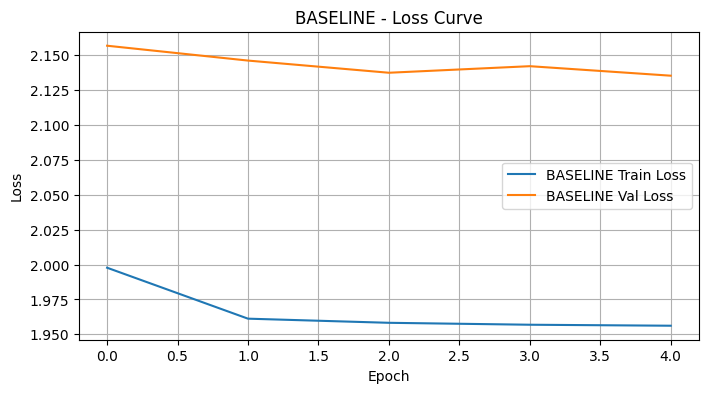

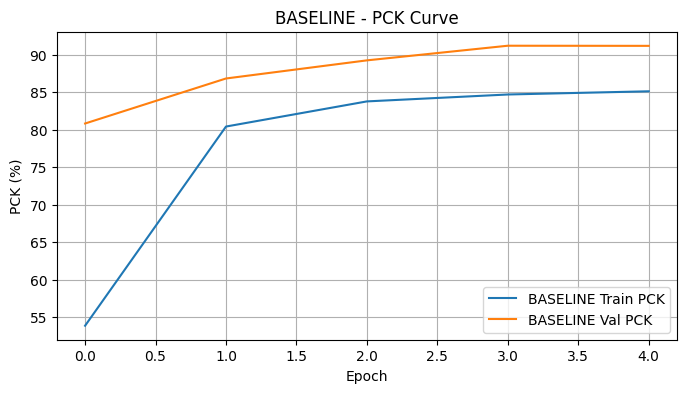

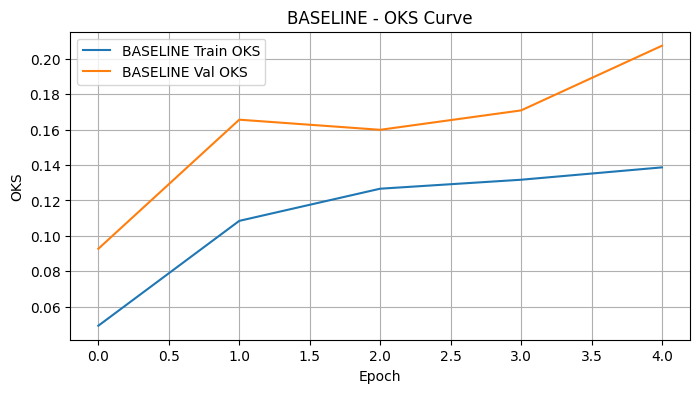

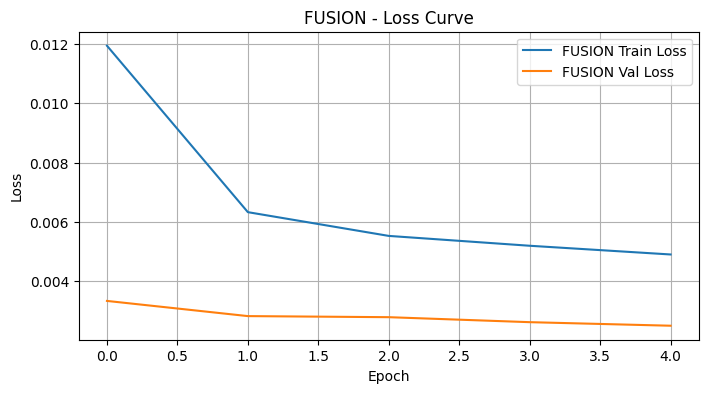

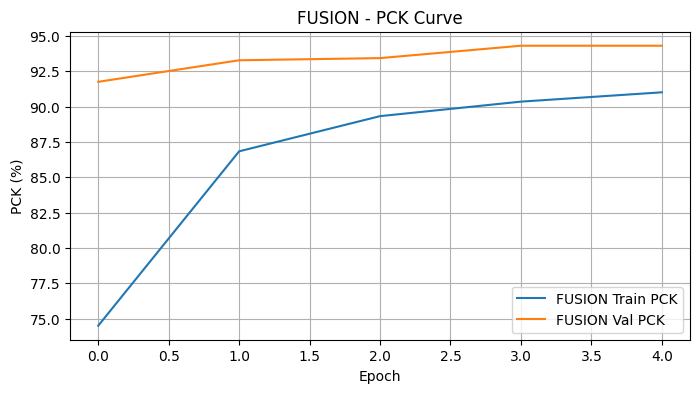

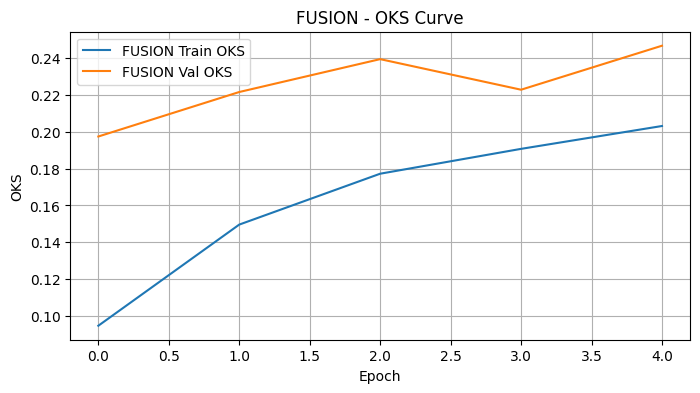

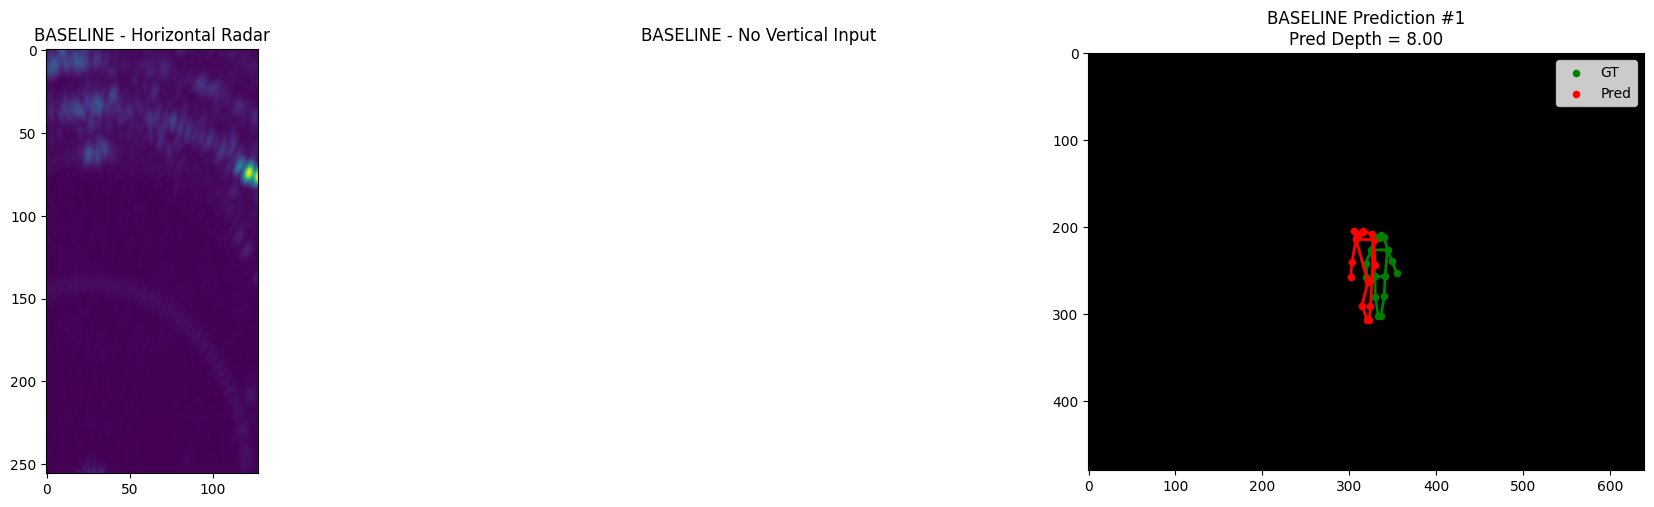

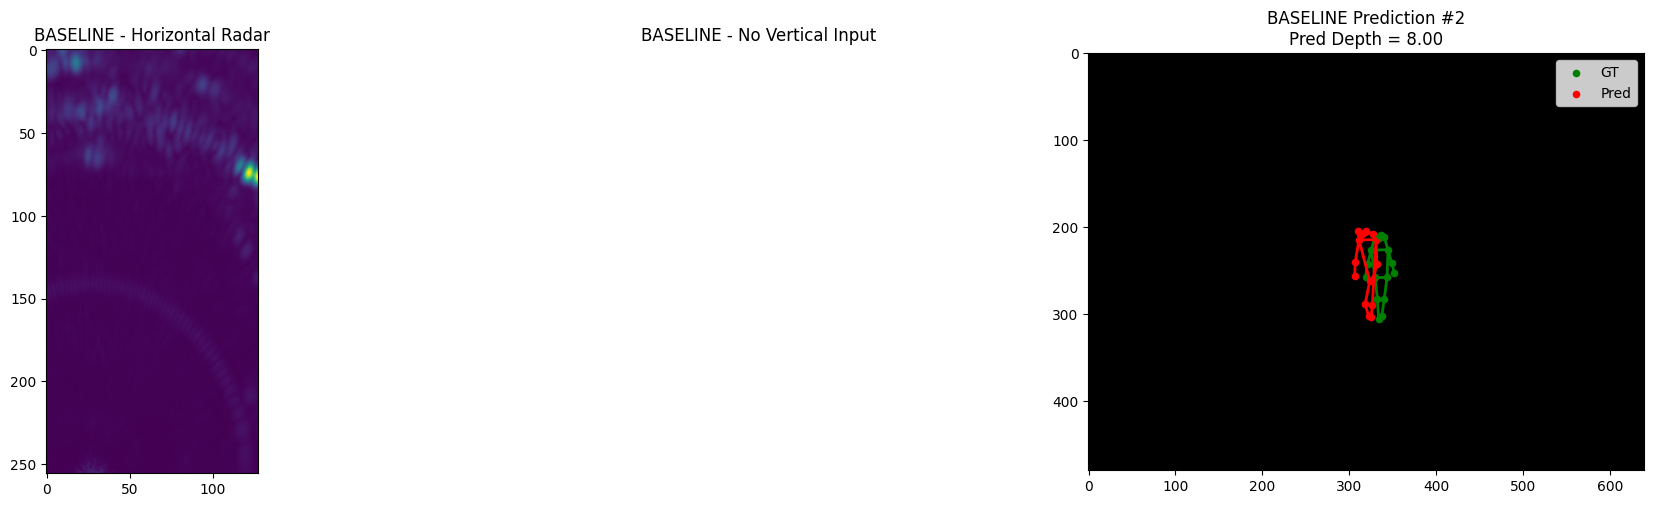

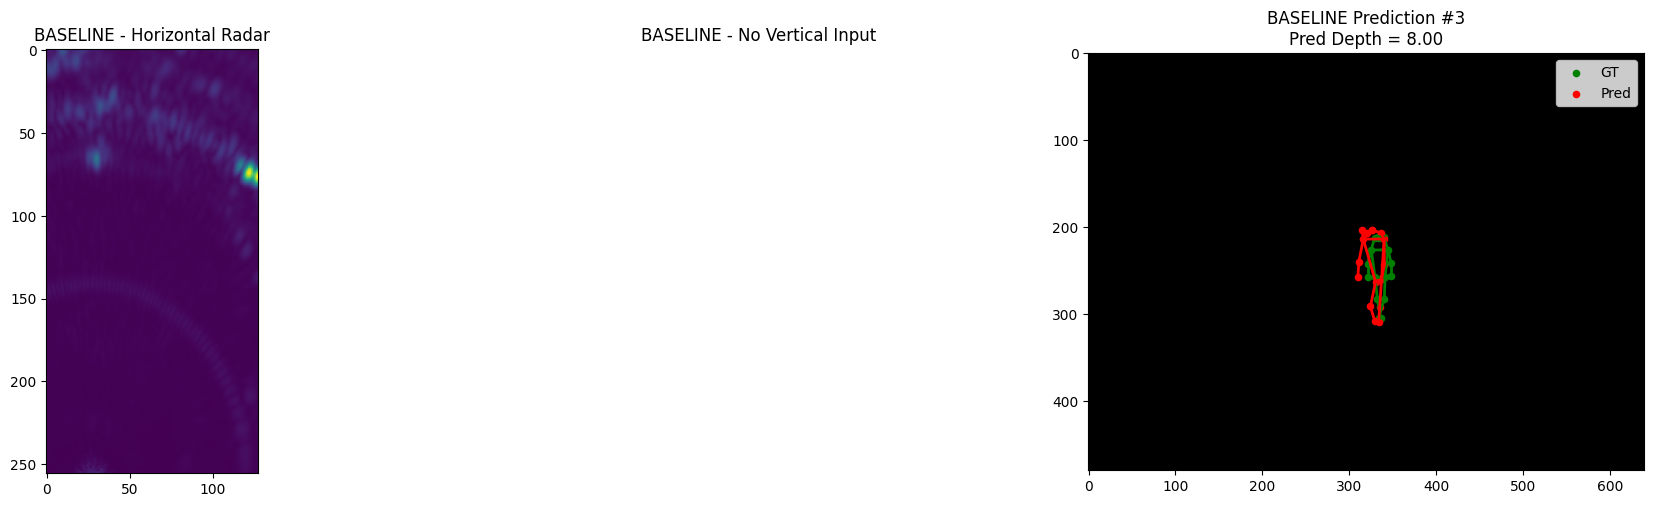

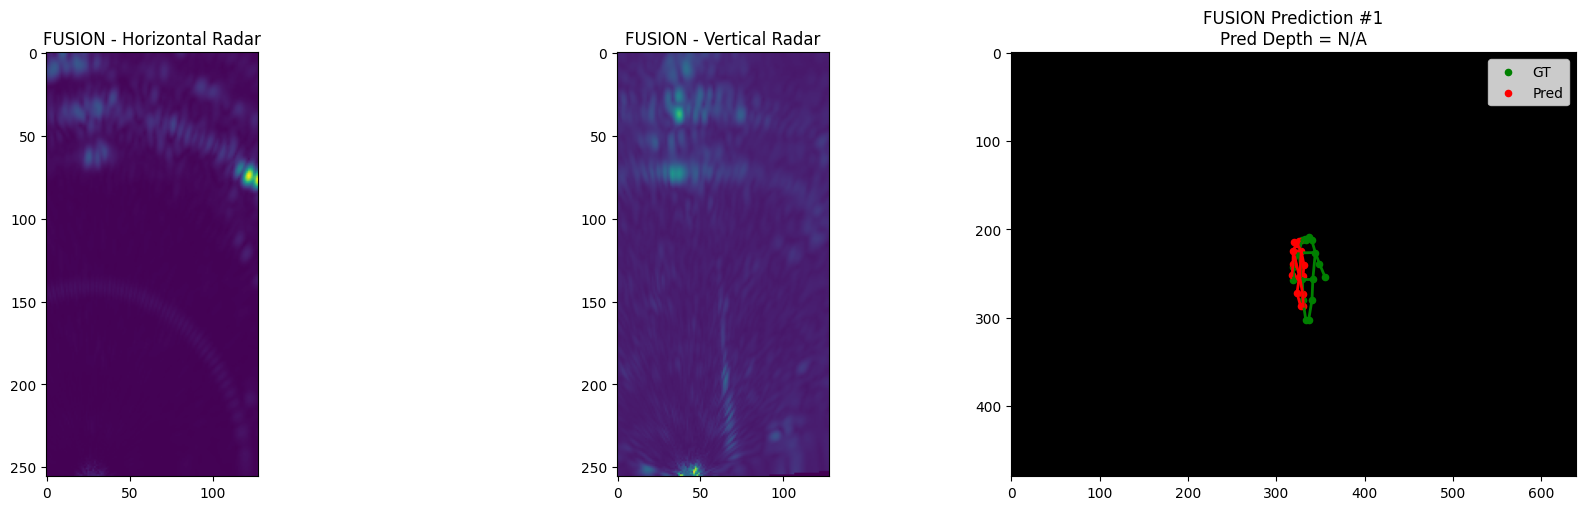

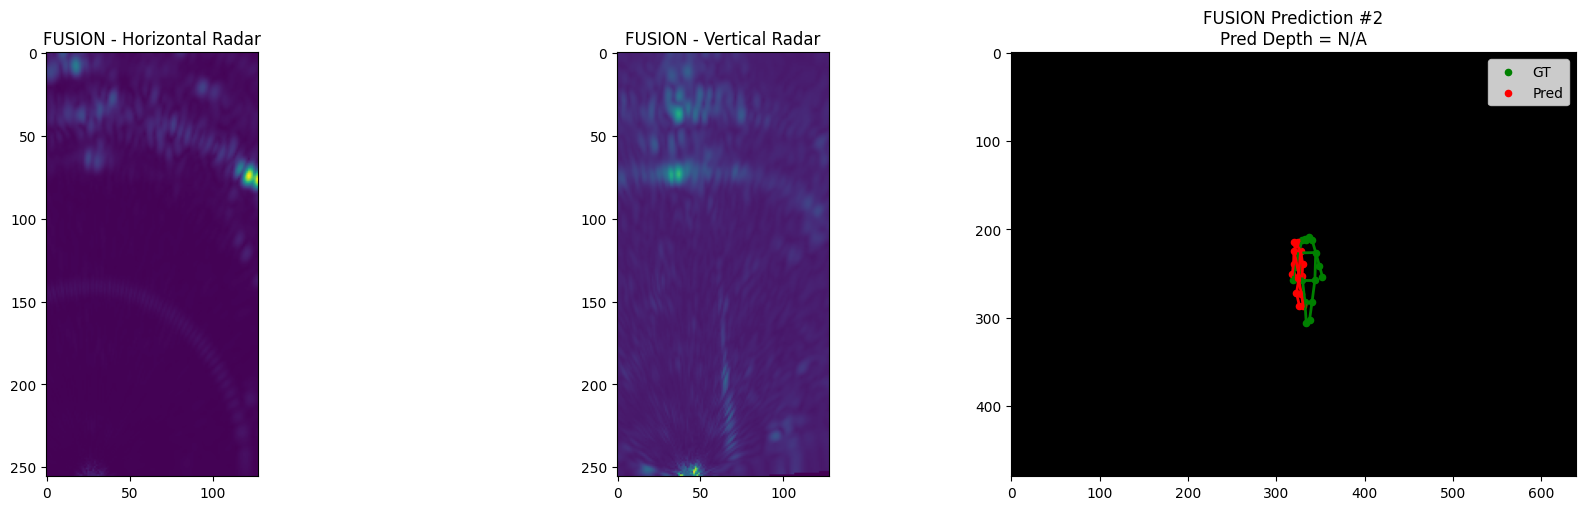

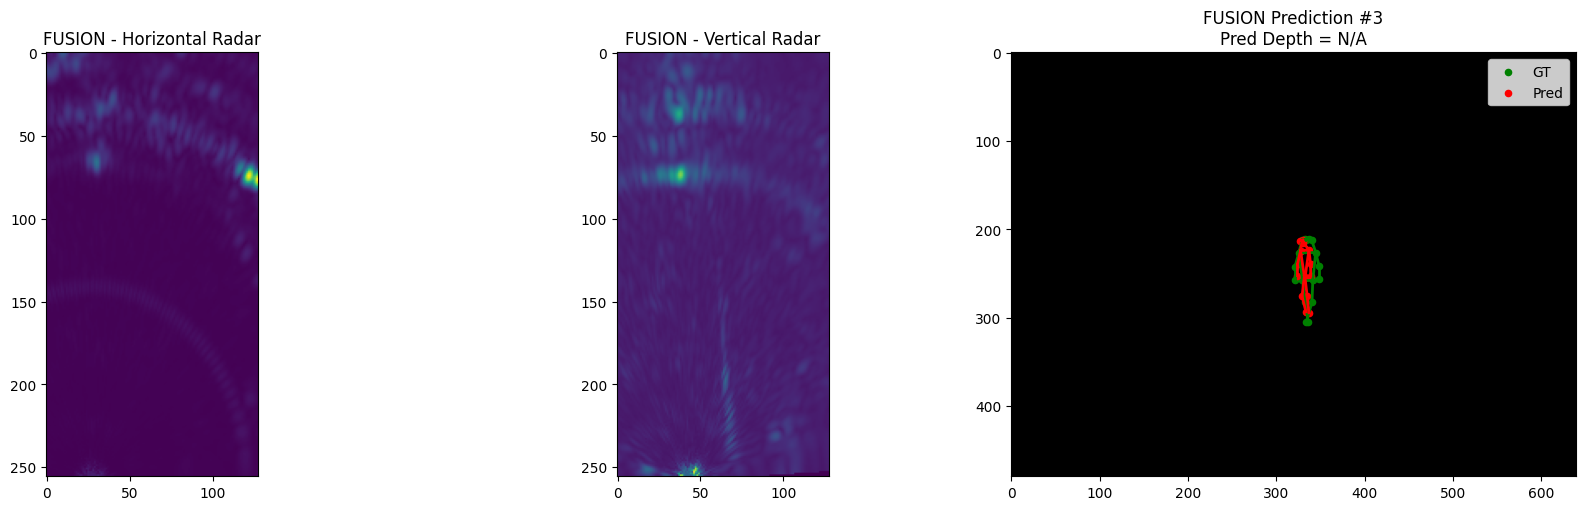

In [ ]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

# =========================================================
# 1. CONFIG
# =========================================================
DATASET_PATH = "P1"
SPLIT_NAME = "P1S1"   # "P1S1" or "P1S2"

# Debug first, then switch to full
FULL_RUN = False

# Runs
RUN_BASELINE = True
RUN_FUSION = True

# Training config
EPOCHS_FULL = 15
EPOCHS_DEBUG = 5
BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42
IMG_W, IMG_H = 640, 480

# Learning rates
LR_BASELINE = 1e-3
LR_FUSION = 1e-4

# Baseline predicts depth; fusion pose-only by default for stability
BASELINE_USE_DEPTH = True
FUSION_USE_DEPTH = False

# Loss weights
BASELINE_DEPTH_WEIGHT = 0.1
FUSION_DEPTH_WEIGHT = 0.01

# Debug subset sizes
DEBUG_TRAIN_SAMPLES = 8000
DEBUG_VAL_SAMPLES = 1000
DEBUG_TEST_SAMPLES = 1000

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else ("cuda" if torch.cuda.is_available() else "cpu")
)

EPOCHS = EPOCHS_FULL if FULL_RUN else EPOCHS_DEBUG

print("====================================================")
print("MMVR Human Pose Project [COMPLETE SAFE VERSION]")
print(f"Device              : {DEVICE}")
print(f"Dataset Path        : {DATASET_PATH}")
print(f"Split               : {SPLIT_NAME}")
print(f"FULL_RUN            : {FULL_RUN}")
print(f"EPOCHS              : {EPOCHS}")
print(f"BATCH_SIZE          : {BATCH_SIZE}")
print(f"RUN_BASELINE        : {RUN_BASELINE}")
print(f"RUN_FUSION          : {RUN_FUSION}")
print(f"BASELINE_USE_DEPTH  : {BASELINE_USE_DEPTH}")
print(f"FUSION_USE_DEPTH    : {FUSION_USE_DEPTH}")
print("====================================================")

# =========================================================
# 2. REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================================================
# 3. CONSTANTS / HELPERS
# =========================================================
SKELETON_CONNECTIONS = np.array([
    [13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
    [3, 5], [4, 6]
], dtype=np.int32)

OKS_SIGMAS = np.array([
    0.026, 0.025, 0.025, 0.035, 0.035,
    0.079, 0.079, 0.072, 0.072, 0.062,
    0.062, 0.107, 0.107, 0.087, 0.087,
    0.089, 0.089
], dtype=np.float32)

def normalize_heatmap(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    mean = x.mean()
    std = x.std()

    if std < 1e-6:
        return np.zeros_like(x, dtype=np.float32)

    x = (x - mean) / std
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return x

def get_relative_path(root_dir, path):
    return os.path.relpath(path, root_dir).replace("\\", "/")

def flatten_split_entries(split_entries):
    out = set()
    if isinstance(split_entries, np.ndarray):
        split_entries = split_entries.tolist()

    for item in split_entries:
        if isinstance(item, bytes):
            item = item.decode("utf-8")
        item = str(item).replace("\\", "/").strip("/")
        out.add(item)

    return out

def masked_mse_loss(pred, gt, valid_mask):
    mask = valid_mask.unsqueeze(-1).float()
    loss = ((pred - gt) ** 2 * mask).sum() / (mask.sum() + 1e-8)
    return loss

def pck_counts(pred, gt, valid_mask, threshold=0.10):
    d = torch.norm(pred - gt, dim=2)
    correct = ((d < threshold) & valid_mask).sum().item()
    total = valid_mask.sum().item()
    return correct, total

def compute_pck(correct, total):
    return 100.0 * correct / total if total > 0 else 0.0

def oks_per_instance(pred_xy, gt_xy, valid_mask, bbox_area, sigmas=OKS_SIGMAS):
    valid = valid_mask.astype(bool)
    if valid.sum() == 0:
        return 0.0

    d2 = np.sum((pred_xy - gt_xy) ** 2, axis=1)
    denom = 2 * (sigmas ** 2) * (bbox_area + 1e-6)
    oks = np.exp(-d2 / (denom + 1e-9))
    return float(np.mean(oks[valid]))

def depth_from_bbox_hori(bbox_hori):
    if bbox_hori is None or len(bbox_hori) == 0:
        return 0.0
    x1, _, x2, _ = bbox_hori[0]
    return float(0.5 * (x1 + x2))

def format_metric(x):
    if x is None:
        return "N/A"
    if isinstance(x, float):
        if np.isnan(x) or np.isinf(x):
            return "N/A"
        return f"{x:.4f}"
    return str(x)

# =========================================================
# 4. DATASET
# =========================================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both", allowed_segments=None):
        self.root_dir = root_dir
        self.view = view
        self.allowed_segments = allowed_segments
        self.samples = []
        self._build_index()

    def _build_index(self):
        for root, _, files in os.walk(self.root_dir):
            rel_dir = get_relative_path(self.root_dir, root)

            if self.allowed_segments is not None:
                if rel_dir not in self.allowed_segments:
                    continue

            radar_files = sorted([f for f in files if f.endswith("_radar.npz")])

            for f in radar_files:
                base = f.replace("_radar.npz", "")
                radar_path = os.path.join(root, f)
                pose_path = os.path.join(root, f"{base}_pose.npz")
                bbox_path = os.path.join(root, f"{base}_bbox.npz")
                meta_path = os.path.join(root, f"{base}_meta.npz")

                if os.path.exists(pose_path) and os.path.exists(bbox_path):
                    self.samples.append({
                        "radar_path": radar_path,
                        "pose_path": pose_path,
                        "bbox_path": bbox_path,
                        "meta_path": meta_path if os.path.exists(meta_path) else None,
                        "segment": rel_dir,
                        "frame_id": base
                    })

        self.samples.sort(key=lambda x: (x["segment"], x["frame_id"]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        radar_data = np.load(s["radar_path"])
        hori = normalize_heatmap(radar_data["hm_hori"])
        vert = normalize_heatmap(radar_data["hm_vert"])

        if self.view == "both":
            radar = np.stack([hori, vert], axis=0)
        elif self.view == "hori":
            radar = np.expand_dims(hori, axis=0)
        else:
            raise ValueError("view must be 'both' or 'hori'")

        radar = np.nan_to_num(radar, nan=0.0, posinf=0.0, neginf=0.0)

        pose_data = np.load(s["pose_path"])
        kp_all = pose_data["kp"]

        kp = kp_all[0].astype(np.float32)
        kp_xy = kp[:, :2].copy()
        kp_score = kp[:, 2].copy()

        valid = (kp_score > 0) & ~((kp[:, 0] == 0) & (kp[:, 1] == 0))

        kp_norm = kp_xy.copy()
        kp_norm[:, 0] /= IMG_W
        kp_norm[:, 1] /= IMG_H
        kp_norm = np.nan_to_num(kp_norm, nan=0.0, posinf=0.0, neginf=0.0)

        bbox_data = np.load(s["bbox_path"])
        bbox_i = bbox_data["bbox_i"]
        bbox_hori = bbox_data["bbox_hori"]

        if len(bbox_i) > 0:
            x1, y1, x2, y2 = bbox_i[0, :4]
            bbox_area = max((x2 - x1) * (y2 - y1), 1.0)
        else:
            bbox_area = 1.0

        depth_target = depth_from_bbox_hori(bbox_hori)

        global_frame_id = -1
        if s["meta_path"] is not None:
            meta = np.load(s["meta_path"])
            if "global_frame_id" in meta:
                global_frame_id = int(meta["global_frame_id"])

        return {
            "radar": torch.tensor(radar, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32),
            "valid": torch.tensor(valid, dtype=torch.bool),
            "bbox_area": torch.tensor(bbox_area, dtype=torch.float32),
            "depth_target": torch.tensor(depth_target, dtype=torch.float32),
            "segment": s["segment"],
            "frame_id": s["frame_id"],
            "global_frame_id": global_frame_id
        }

# =========================================================
# 5. MODELS
# =========================================================
class BaselinePoseDepthModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        self.pose_head = nn.Linear(512, 17 * 2)
        self.depth_head = nn.Linear(512, 1)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.shared_fc(feat)

        pose = torch.sigmoid(self.pose_head(feat)).view(-1, 17, 2)
        depth = torch.clamp(self.depth_head(feat).squeeze(1), min=0.0, max=8.0)

        return {"pose": pose, "depth": depth}


class _FusionBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

    def forward(self, x):
        return self.branch(x)


class FusionTwoBranchModel(nn.Module):
    def __init__(self, use_depth=False):
        super().__init__()
        self.use_depth = use_depth

        self.hori_branch = _FusionBranch()
        self.vert_branch = _FusionBranch()

        self.fusion_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )

        self.pose_head = nn.Linear(256, 17 * 2)
        self.depth_head = nn.Linear(256, 1) if use_depth else None

    def forward(self, x):
        x_h = x[:, 0:1]
        x_v = x[:, 1:2]

        f_h = self.hori_branch(x_h)
        f_v = self.vert_branch(x_v)

        feat = torch.cat([f_h, f_v], dim=1)
        feat = self.fusion_fc(feat)

        pose = torch.sigmoid(self.pose_head(feat)).view(-1, 17, 2)

        if self.use_depth:
            depth = torch.clamp(self.depth_head(feat).squeeze(1), min=0.0, max=8.0)
        else:
            depth = None

        return {"pose": pose, "depth": depth}

# =========================================================
# 6. SPLITS
# =========================================================
def load_split(dataset_path, split_name="P1S1"):
    split_file = os.path.join(dataset_path, "data_split.npz")
    if not os.path.exists(split_file):
        raise FileNotFoundError(f"Missing split file: {split_file}")

    data = np.load(split_file, allow_pickle=True)
    split_dict = data["data_split_dict"].item()

    if split_name not in split_dict:
        raise ValueError(f"{split_name} not found in split file")

    info = split_dict[split_name]
    train_segments = flatten_split_entries(info["train"])
    val_segments = flatten_split_entries(info["val"])
    test_segments = flatten_split_entries(info["test"])
    return train_segments, val_segments, test_segments

# =========================================================
# 7. TRAIN / EVAL
# =========================================================
def run_epoch(model, loader, model_name, optimizer=None, use_depth=False, depth_weight=0.1):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_pose_loss = 0.0
    total_depth_loss = 0.0

    total_correct = 0
    total_valid = 0
    oks_scores = []
    depth_abs_errors = []

    valid_batches = 0

    for batch in loader:
        radar = torch.nan_to_num(batch["radar"].to(DEVICE), nan=0.0, posinf=0.0, neginf=0.0)
        gt_kp = torch.nan_to_num(batch["keypoints"].to(DEVICE), nan=0.0, posinf=0.0, neginf=0.0)
        valid = batch["valid"].to(DEVICE)
        gt_depth = torch.nan_to_num(batch["depth_target"].to(DEVICE), nan=0.0, posinf=0.0, neginf=0.0)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(radar)
            pred_kp = torch.nan_to_num(outputs["pose"], nan=0.0, posinf=0.0, neginf=0.0)
            pred_depth = outputs["depth"]

            pose_loss = masked_mse_loss(pred_kp, gt_kp, valid)

            if use_depth and pred_depth is not None:
                pred_depth = torch.nan_to_num(pred_depth, nan=0.0, posinf=0.0, neginf=0.0)
                depth_loss = F.l1_loss(pred_depth, gt_depth)
                loss = pose_loss + depth_weight * depth_loss
            else:
                depth_loss = torch.tensor(0.0, device=DEVICE)
                loss = pose_loss

            if not torch.isfinite(loss):
                print(f"[WARNING] {model_name}: non-finite loss batch skipped")
                continue

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        valid_batches += 1
        total_loss += loss.item()
        total_pose_loss += pose_loss.item()
        total_depth_loss += depth_loss.item()

        c, t = pck_counts(pred_kp.detach(), gt_kp.detach(), valid.detach(), threshold=0.10)
        total_correct += c
        total_valid += t

        pred_np = pred_kp.detach().cpu().numpy()
        gt_np = gt_kp.detach().cpu().numpy()
        valid_np = valid.detach().cpu().numpy()
        bbox_area_np = batch["bbox_area"].cpu().numpy()

        for i in range(len(pred_np)):
            pred_px = pred_np[i] * np.array([IMG_W, IMG_H], dtype=np.float32)
            gt_px = gt_np[i] * np.array([IMG_W, IMG_H], dtype=np.float32)
            oks_scores.append(
                oks_per_instance(pred_px, gt_px, valid_np[i], float(bbox_area_np[i]))
            )

        if use_depth and pred_depth is not None:
            pred_depth_np = pred_depth.detach().cpu().numpy()
            gt_depth_np = gt_depth.detach().cpu().numpy()
            depth_abs_errors.extend(np.abs(pred_depth_np - gt_depth_np).tolist())

    if valid_batches == 0:
        return {
            "loss": None,
            "pose_loss": None,
            "depth_loss": None,
            "pck": 0.0,
            "oks": None,
            "depth_mae": None
        }

    avg_loss = total_loss / valid_batches
    avg_pose_loss = total_pose_loss / valid_batches
    avg_depth_loss = total_depth_loss / valid_batches
    avg_pck = compute_pck(total_correct, total_valid)
    avg_oks = float(np.mean(oks_scores)) if len(oks_scores) > 0 else None
    depth_mae = float(np.mean(depth_abs_errors)) if len(depth_abs_errors) > 0 else None

    return {
        "loss": avg_loss,
        "pose_loss": avg_pose_loss,
        "depth_loss": avg_depth_loss,
        "pck": avg_pck,
        "oks": avg_oks,
        "depth_mae": depth_mae
    }

# =========================================================
# 8. EXPERIMENT RUNNER
# =========================================================
def train_and_evaluate(model_name):
    if model_name == "BASELINE":
        view = "hori"
        lr = LR_BASELINE
        use_depth = BASELINE_USE_DEPTH
        depth_weight = BASELINE_DEPTH_WEIGHT
        model = BaselinePoseDepthModel().to(DEVICE)
    elif model_name == "FUSION":
        view = "both"
        lr = LR_FUSION
        use_depth = FUSION_USE_DEPTH
        depth_weight = FUSION_DEPTH_WEIGHT
        model = FusionTwoBranchModel(use_depth=FUSION_USE_DEPTH).to(DEVICE)
    else:
        raise ValueError("model_name must be BASELINE or FUSION")

    print("\n====================================================")
    print(f"STARTING MODEL : {model_name}")
    print(f"INPUT VIEW     : {view}")
    print(f"LEARNING RATE  : {lr}")
    print(f"USE DEPTH      : {use_depth}")
    print("====================================================")

    train_segments, val_segments, test_segments = load_split(DATASET_PATH, SPLIT_NAME)

    train_dataset = RadarPoseDataset(DATASET_PATH, view=view, allowed_segments=train_segments)
    val_dataset   = RadarPoseDataset(DATASET_PATH, view=view, allowed_segments=val_segments)
    test_dataset  = RadarPoseDataset(DATASET_PATH, view=view, allowed_segments=test_segments)

    print(f"[{model_name}] FULL Train samples: {len(train_dataset)}")
    print(f"[{model_name}] FULL Val samples  : {len(val_dataset)}")
    print(f"[{model_name}] FULL Test samples : {len(test_dataset)}")

    if not FULL_RUN:
        train_dataset = Subset(train_dataset, range(min(DEBUG_TRAIN_SAMPLES, len(train_dataset))))
        val_dataset   = Subset(val_dataset, range(min(DEBUG_VAL_SAMPLES, len(val_dataset))))
        test_dataset  = Subset(test_dataset, range(min(DEBUG_TEST_SAMPLES, len(test_dataset))))

        print(f"[{model_name}] DEBUG Train samples: {len(train_dataset)}")
        print(f"[{model_name}] DEBUG Val samples  : {len(val_dataset)}")
        print(f"[{model_name}] DEBUG Test samples : {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train": [],
        "val": []
    }

    best_val_pck = -1.0
    save_prefix = "full" if FULL_RUN else "debug"
    best_path = f"{save_prefix}_best_{model_name.lower()}_{SPLIT_NAME.lower()}.pth"

    for epoch in range(EPOCHS):
        train_metrics = run_epoch(
            model, train_loader, model_name=model_name,
            optimizer=optimizer, use_depth=use_depth, depth_weight=depth_weight
        )
        val_metrics = run_epoch(
            model, val_loader, model_name=model_name,
            optimizer=None, use_depth=use_depth, depth_weight=depth_weight
        )

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        if val_metrics["pck"] > best_val_pck:
            best_val_pck = val_metrics["pck"]
            torch.save(model.state_dict(), best_path)

        print(
            f"[{model_name}] Epoch [{epoch+1:02d}/{EPOCHS}] | "
            f"Train PCK: {train_metrics['pck']:.2f}% | "
            f"Val PCK: {val_metrics['pck']:.2f}% | "
            f"Val OKS: {format_metric(val_metrics['oks'])} | "
            f"Val Depth MAE: {format_metric(val_metrics['depth_mae'])}"
        )

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    test_metrics = run_epoch(
        model, test_loader, model_name=model_name,
        optimizer=None, use_depth=use_depth, depth_weight=depth_weight
    )

    print(f"\n[{model_name}] FINAL TEST METRICS")
    print(json.dumps({
        "loss": test_metrics["loss"],
        "pose_loss": test_metrics["pose_loss"],
        "depth_loss": test_metrics["depth_loss"],
        "pck": test_metrics["pck"],
        "oks": test_metrics["oks"],
        "depth_mae": test_metrics["depth_mae"]
    }, indent=2))

    hist_path = f"{save_prefix}_history_{model_name.lower()}_{SPLIT_NAME.lower()}.json"
    with open(hist_path, "w") as f:
        json.dump(history, f, indent=2)

    return {
        "model_name": model_name,
        "view": view,
        "use_depth": use_depth,
        "best_model_path": best_path,
        "history": history,
        "test_metrics": test_metrics,
        "test_dataset": test_dataset,
        "model": model
    }

# =========================================================
# 9. RUN MODELS
# =========================================================
results = []

if RUN_BASELINE:
    results.append(train_and_evaluate("BASELINE"))

if RUN_FUSION:
    results.append(train_and_evaluate("FUSION"))

# =========================================================
# 10. FINAL COMPARISON TABLE
# =========================================================
print("\n====================================================")
print("FINAL COMPARISON TABLE")
print("====================================================")
print(f"{'Model':<12} {'PCK (%)':<10} {'OKS':<10} {'Depth MAE':<12} {'Loss':<10}")
for res in results:
    m = res["test_metrics"]
    print(
        f"{res['model_name']:<12} "
        f"{m['pck']:<10.2f} "
        f"{format_metric(m['oks']):<10} "
        f"{format_metric(m['depth_mae']):<12} "
        f"{format_metric(m['loss']):<10}"
    )

# =========================================================
# 11. PLOT TRAINING CURVES
# =========================================================
def plot_history(history, model_tag):
    train_pck = [x["pck"] for x in history["train"]]
    val_pck = [x["pck"] for x in history["val"]]
    train_oks = [np.nan if x["oks"] is None else x["oks"] for x in history["train"]]
    val_oks = [np.nan if x["oks"] is None else x["oks"] for x in history["val"]]
    train_loss = [np.nan if x["loss"] is None else x["loss"] for x in history["train"]]
    val_loss = [np.nan if x["loss"] is None else x["loss"] for x in history["val"]]

    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label=f"{model_tag} Train Loss")
    plt.plot(val_loss, label=f"{model_tag} Val Loss")
    plt.title(f"{model_tag} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_pck, label=f"{model_tag} Train PCK")
    plt.plot(val_pck, label=f"{model_tag} Val PCK")
    plt.title(f"{model_tag} - PCK Curve")
    plt.xlabel("Epoch")
    plt.ylabel("PCK (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(train_oks, label=f"{model_tag} Train OKS")
    plt.plot(val_oks, label=f"{model_tag} Val OKS")
    plt.title(f"{model_tag} - OKS Curve")
    plt.xlabel("Epoch")
    plt.ylabel("OKS")
    plt.legend()
    plt.grid(True)
    plt.show()

for res in results:
    plot_history(res["history"], res["model_name"])

# =========================================================
# 12. VISUALIZATION
# =========================================================
def draw_pose(ax, kp_px, valid, color, label=None):
    for c in SKELETON_CONNECTIONS:
        i, j = c
        if valid[i] and valid[j]:
            p1, p2 = kp_px[i], kp_px[j]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=2)
    pts = kp_px[valid]
    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], c=color, s=20, label=label)

def show_predictions(result_obj, num_samples=3):
    model = result_obj["model"]
    dataset = result_obj["test_dataset"]
    model_name = result_obj["model_name"]
    model.eval()

    n = min(num_samples, len(dataset))
    for idx in range(n):
        sample = dataset[idx]
        radar = sample["radar"].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            outputs = model(radar)

        pred_kp = outputs["pose"].cpu().numpy()[0]
        pred_depth = outputs["depth"]
        gt_kp = sample["keypoints"].numpy()
        valid = sample["valid"].numpy()

        pred_px = pred_kp * np.array([IMG_W, IMG_H], dtype=np.float32)
        gt_px = gt_kp * np.array([IMG_W, IMG_H], dtype=np.float32)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].imshow(sample["radar"][0].numpy())
        axes[0].set_title(f"{model_name} - Horizontal Radar")

        if sample["radar"].shape[0] == 2:
            axes[1].imshow(sample["radar"][1].numpy())
            axes[1].set_title(f"{model_name} - Vertical Radar")
        else:
            axes[1].axis("off")
            axes[1].set_title(f"{model_name} - No Vertical Input")

        canvas = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
        axes[2].imshow(canvas)
        draw_pose(axes[2], gt_px, valid, color="g", label="GT")
        draw_pose(axes[2], pred_px, valid, color="r", label="Pred")

        depth_text = "N/A" if pred_depth is None else f"{float(pred_depth.cpu().numpy()[0]):.2f}"
        axes[2].set_title(
            f"{model_name} Prediction #{idx+1}\n"
            f"Pred Depth = {depth_text}"
        )
        axes[2].legend()

        plt.tight_layout()
        plt.show()

for res in results:
    show_predictions(res, num_samples=3)